# BT Neural Network for option price in BS model

## 📋 План работы над дипломом (ВКР)

### 🎯 Ключевые даты

| Событие | Дата |
|---------|------|
| Предзащиты (по пятницам, раз в 2 недели) | 20 мар ✅ / 3 апр / **17 апр** ← сейчас |
| Размещение работы на сайте университета | 15 мая |
| **Защита ВКР** | **15 июня** |
| Антиплагиат (макс. 3 попытки на платной версии) | до защиты |

---

### 🧠 1. Проблематика и мотивация (для слайдов)

> ⏱ **7 минут, 15 слайдов**

**Проблема:**
- Оценка американских опционов — **трудная и нерешённая задача**
- Нет аналитической формулы (в отличие от европейских)
- Численные методы сложны из-за **подвижной границы** → задача сводится к решению PDE с частными производными

**Идея решения:**
- Использовать **нейронную сеть в форме биномиального дерева**
- Обучить на европейских опционах (где есть эталон — Black–Scholes)
- Заменить активации в скрытых слоях на **maxout** → применить к американским

---

### 🧪 2. Экспериментальный план

| Шаг | Действие |
|-----|----------|
| 1 | Взять цены европейских опционов из **модели Блэка–Шоулза–Мертона** (BSM) |
| 2 | Обучить нейросеть на европейских данных |
| 3 | Заменить активации на **maxout** → применить к американским опционам |
| 4 | Проверить на эталонных ценах американских опционов из **QuantLib** |
| 5 | Сравнить результаты (MAE, RMSE, графики) |

> **Критерий успеха:** предсказания нейросети близки к QuantLib-значениям

---

### 📊 3. Ожидаемые результаты

- ✅ Реализован алгоритм из статьи Шорохова (2024)
- ✅ Нейросеть обучена на европейских опционах (BSM)
- ✅ **Численно доказана применимость к американским опционам**
- 📄 Возможна публикация статьи в студенческую конференцию
- 💾 Возможна регистрация программы в Роспатенте (НИР → диплом)

---

### 🔄 4. Дальнейшее развитие / What's next?

| Отказ от BSM с постоянной волатильностью | → Переход к **локальной волатильности** σ(S,t) |
|-------------------------------------------|------------------------------------------------|
| Альтернатива | Биномиальные модели для **непостоянной волатильности** (Dupire и др.) |

> 🎯 **Цель:** найти/разработать модель, которая умеет считать **американские опционы с локальной волатильностью**

---

### 📁 5. Организационные моменты

| Вопрос | Решение |
|--------|---------|
| Размещение кода | GitHub (публичный/доступ для комиссии) |
| Код в дипломе | Можно вставить в текст **или** вынести в приложение |
| Предзащиты | По пятницам, раз в 2 недели. **Ближайшая — 17 апреля** |
| Антиплагиат | До 3 попыток на платной версии — использовать аккуратно |

---

### ✅ 6. Чек-лист к 17 апреля (ближайшая предзащита)

- [ ] Сформулировать **задачу** чётко (1 слайд)
- [ ] Описать **текущее состояние работы** (что сделано, что нет)
- [ ] Показать **первые результаты** (графики, таблицы ошибок)
- [ ] Обозначить **план до защиты** (15 мая → 15 июня)

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
from scipy.stats import norm
from torchinfo import summary
import os

## MyIBT_CRR
Implied Binomial Tree - Cox-Ross-Rubinstein is a Python class that implements an implied binomial tree model for option pricing. This model extends the classical CRR binomial tree by allowing state-dependent volatility through a user-defined function, making it particularly useful for pricing options under more realistic market conditions where volatility depends on both asset price and time.

## Пакет `btnn_bs`

Код вынесен в каталог `btnn_bs/` в корне репозитория. Установка из корня: `pip install -e .` (или добавьте корень репозитория в `PYTHONPATH` / `sys.path`).


In [ ]:
from btnn_bs import (
    MyIBT_CRR,
    BTNetEuropean,
    BTNetAmerican,
    train_BTNet,
    bs_put_price,
    american_put_prices_binomial,
    plot_comparison,
    plot_errors,
    plot_training_losses,
)


## Test

In [50]:
# The paper parameters
S0 = 0.5
t0 = 0.0
T = 1.0
r = 0.05
sig = 0.25
n_dim = 9 # periods

# Generate Train
K_min, K_max = 0.25, 0.75
nK = 500

# Sample
K_samples = np.random.uniform(K_min, K_max, nK).reshape(-1, 1)
K_test = np.linspace(K_min, K_max, 51).reshape(-1, 1)

In [51]:
crr_tree = MyIBT_CRR(n=n_dim)

crr_tree.build(
    S0=S0,
    t0=t0,
    T=T,
    r=r,
    sigma=lambda S, t, teta: sig,
    teta=None
)

### Test European Put Option

In [52]:
prices_euro = bs_put_price(S0, K_samples, T, r, sig).reshape(-1, 1)

model_european = BTNetEuropean(n_dim, S0, sig, T, t0, r)

loss_hist_european = train_BTNet(
    model=model_european,
    K_train=K_samples,
    prices_train=prices_euro,
    epochs=200,
    lr=0.01
)

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch [50/200], Loss: 0.000000
Epoch [100/200], Loss: 0.000000
Epoch [150/200], Loss: 0.000000
Epoch [200/200], Loss: 0.000000


In [53]:
predictions_european = model_european.predict(K_test)
true_prices = bs_put_price(S0, K_test, T, r, sig)
crr_prices_european = np.array(
    [
        crr_tree.eval_european_put(K) for K in K_test.flatten()
    ]
)

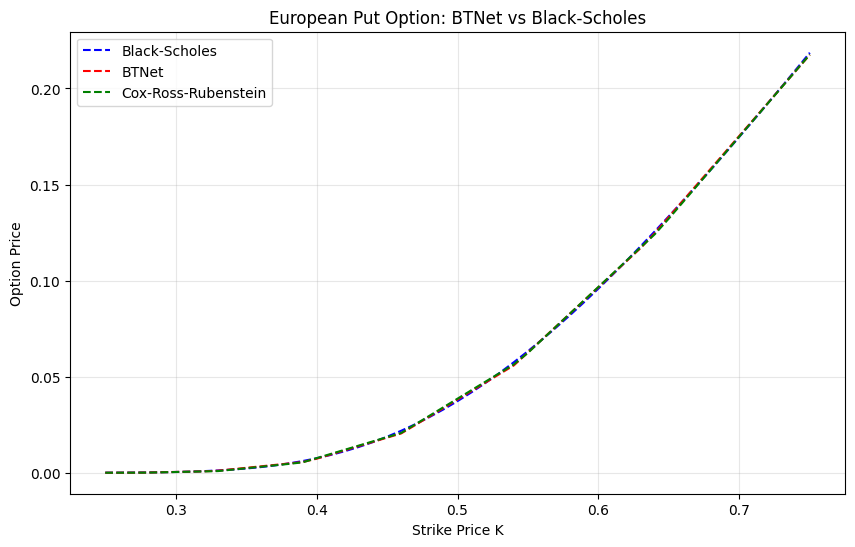

In [54]:
plot_comparison(
    K=K_test,
    bs_prices=true_prices,
    nn_prices=predictions_european,
    crr_prices=crr_prices_european,
    title="European Put Option: BTNet vs Black-Scholes"
)

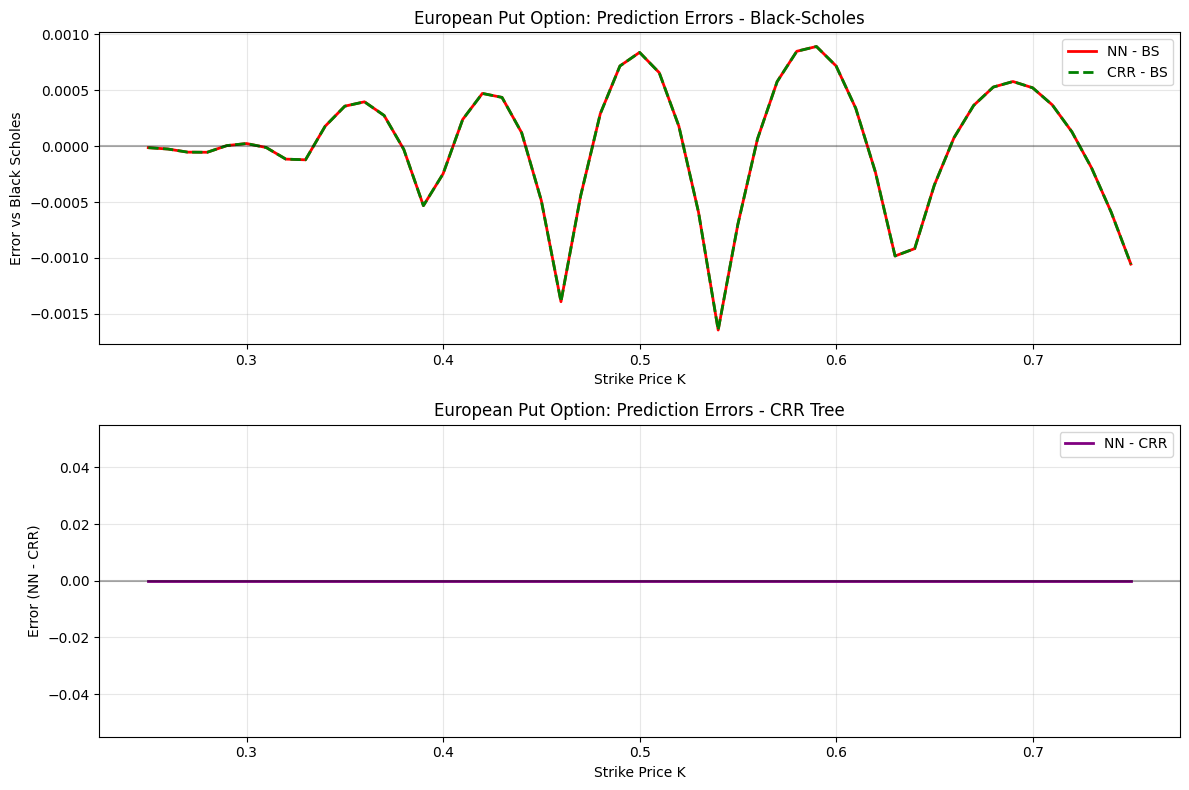

In [55]:
plot_errors(
    K=K_test,
    bs_prices=true_prices,
    nn_prices=predictions_european,
    crr_prices=crr_prices_european,
    title="European Put Option: Prediction Errors"
)

### Test American Put Option

In [56]:
prices_american = np.array(
    [
        american_put_prices_binomial(
            S0=S0,
            K=K,
            T=T,
            r=r,
            sigma=sig,
            n=100
        )
        for K in K_samples.flatten()
    ]
).reshape(-1, 1)

In [57]:
model_american = BTNetAmerican(
    n_dim=n_dim,
    S0=S0,
    sig=sig,
    T=T,
    t0=t0,
    r=r
)

loss_hist_american = train_BTNet(
    model=model_american,
    K_train=K_samples,
    prices_train=prices_american,
    epochs=200,
    lr=0.01
)

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch [50/200], Loss: 0.000014
Epoch [100/200], Loss: 0.000006
Epoch [150/200], Loss: 0.000002
Epoch [200/200], Loss: 0.000002


In [58]:
predictions_american = model_american.predict(K_test).flatten()
true_prices_american = np.array(
    [
        american_put_prices_binomial(
            S0=S0,
            K=K,
            T=T,
            r=r,
            sigma=sig,
            n=100
        )
        for K in K_test.flatten()
    ]
)
crr_prices_american = np.array(
    [
        crr_tree.eval_american_put(K) for K in K_test.flatten()
    ]
)

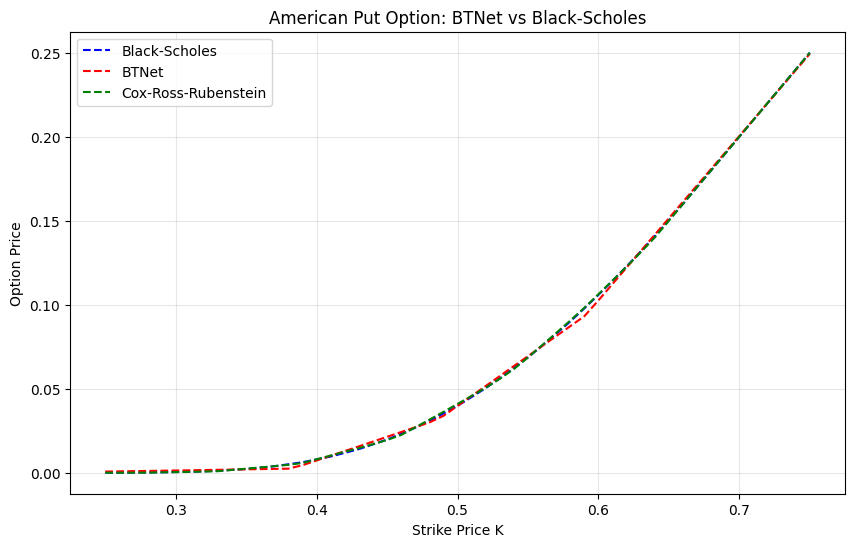

In [59]:
plot_comparison(
    K=K_test,
    bs_prices=true_prices_american,
    nn_prices=predictions_american,
    crr_prices=crr_prices_american,
    title="American Put Option: BTNet vs Black-Scholes"
)

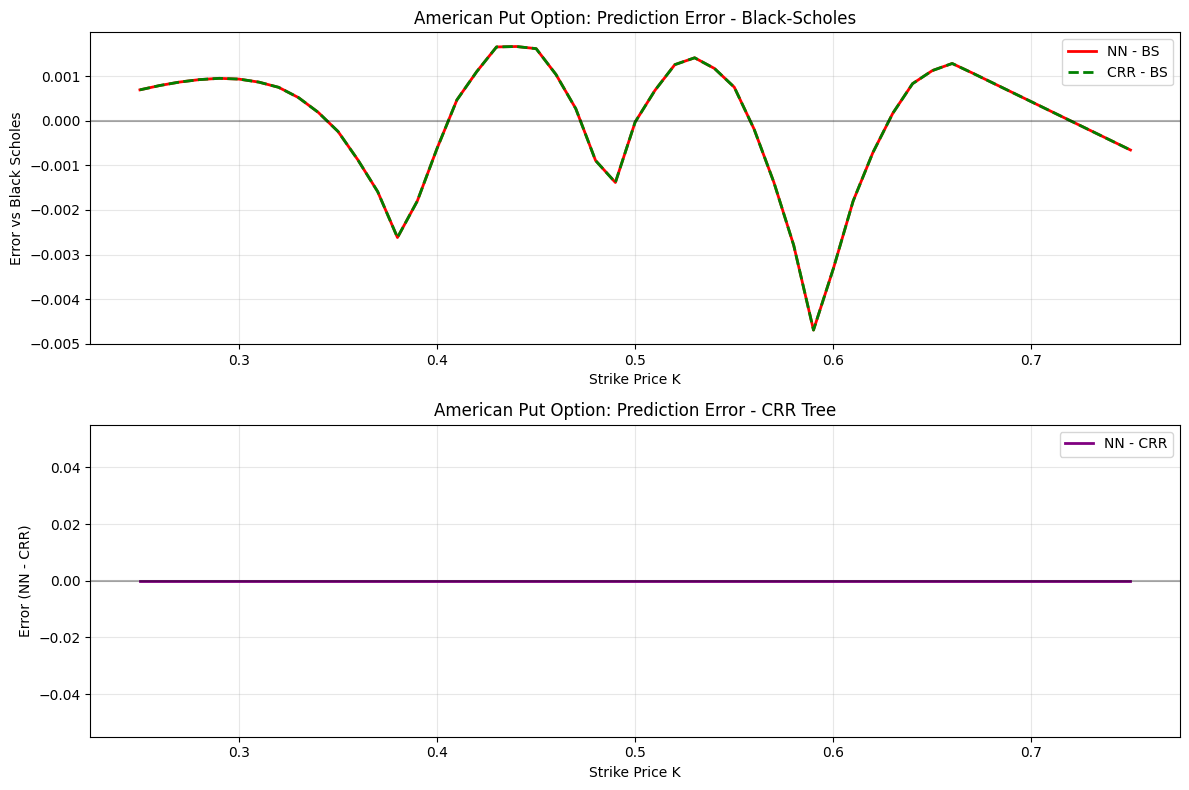

In [60]:
plot_errors(
    K=K_test,
    bs_prices=true_prices_american,
    nn_prices=predictions_american,
    crr_prices=crr_prices_american,
    title="American Put Option: Prediction Error"
)

## Training Losses: European and American

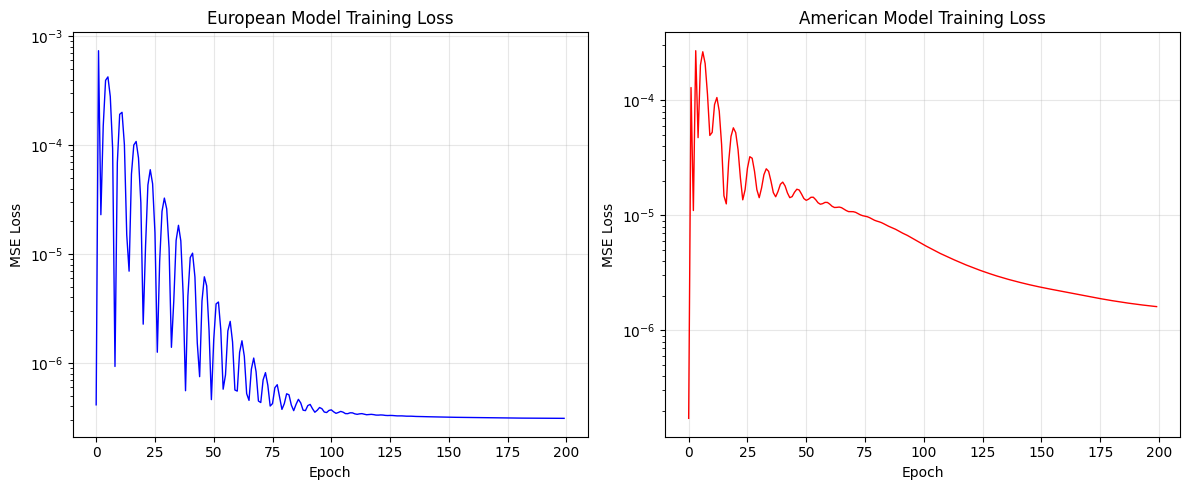

In [61]:
plot_training_losses(
    loss_hist_euro=loss_hist_european,
    loss_hist_amer=loss_hist_american
)

## Architectures

In [33]:
base_path = "./outputs"

os.mkdir("./outputs")

### BTNetEuropean

In [34]:
summary(model_european, input_size=(1, 1))

Layer (type:depth-idx)                   Output Shape              Param #
BTNetEuropean                            [1]                       --
├─DenseLayer: 1-1                        [1, 10]                   --
│    └─Linear: 2-1                       [1, 10]                   20
├─ConvLayer: 1-2                         [1, 9]                    --
│    └─Conv1d: 2-2                       [1, 1, 9]                 2
├─ConvLayer: 1-3                         [1, 8]                    (recursive)
│    └─Conv1d: 2-3                       [1, 1, 8]                 (recursive)
├─ConvLayer: 1-4                         [1, 7]                    (recursive)
│    └─Conv1d: 2-4                       [1, 1, 7]                 (recursive)
├─ConvLayer: 1-5                         [1, 6]                    (recursive)
│    └─Conv1d: 2-5                       [1, 1, 6]                 (recursive)
├─ConvLayer: 1-6                         [1, 5]                    (recursive)
│    └─Conv1d: 2-6     

In [35]:
torch.onnx.export(model_european, torch.randn(1, 1), f"{base_path}/model_european.onnx")

W0414 21:13:15.236000 43512 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0414 21:13:15.237000 43512 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0414 21:13:15.237000 43512 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `BTNetEuropean([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BTNetEuropean([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 9 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.11.0',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"k"<FLOAT,[1,1]>
            ),
            outputs=(
                %"squeeze_9"<FLOAT,[1]>
            ),
            initializers=(
                %"_initial_layer._linear.weight"<FLOAT,[10,1]>{TorchTensor<FLOAT,[10,1]>(Parameter containing: tensor([[1.0005], [0.9993], [0.9975], [0.9959], [0.9966], [1.0009], [1.0023], [1.0000], [1.0000], [1.0000]], requires_grad=True), name='_initial_layer._linear.weight')},
                %"_initial_layer._linear.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.2312, -0.2756, -0.3298, -0.3916, -0.4600, -0.5426, -0.6384, -0.7584, -0.8960, -1.0585], requires_grad=True), name='_initial_layer._linear.bias')}

### BTNetAmerican

In [36]:
summary(model_american, input_size=(1, 1))

Layer (type:depth-idx)                   Output Shape              Param #
BTNetAmerican                            [1, 1]                    --
├─DenseLayer: 1-1                        [1, 10]                   --
│    └─Linear: 2-1                       [1, 10]                   20
├─ModuleList: 1-2                        --                        --
│    └─MaxoutLayer: 2-2                  [1, 9]                    --
│    │    └─Conv1d: 3-1                  [1, 1, 9]                 2
│    │    └─Linear: 3-2                  [1, 9]                    18
│    └─MaxoutLayer: 2-3                  [1, 8]                    --
│    │    └─Conv1d: 3-3                  [1, 1, 8]                 2
│    │    └─Linear: 3-4                  [1, 8]                    16
│    └─MaxoutLayer: 2-4                  [1, 7]                    --
│    │    └─Conv1d: 3-5                  [1, 1, 7]                 2
│    │    └─Linear: 3-6                  [1, 7]                    14
│    └─MaxoutLayer

In [37]:
torch.onnx.export(model_american, torch.randn(1, 1), f"{base_path}/model_american.onnx")

W0414 21:13:23.294000 43512 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0414 21:13:23.294000 43512 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0414 21:13:23.294000 43512 torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Obtain model graph for `BTNetAmerican([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BTNetAmerican([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 9 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.11.0',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"k"<FLOAT,[1,1]>
            ),
            outputs=(
                %"maximum_8"<FLOAT,[1,1]>
            ),
            initializers=(
                %"_initial_layer._linear.weight"<FLOAT,[10,1]>{TorchTensor<FLOAT,[10,1]>(Parameter containing: tensor([[0.9579], [0.8259], [0.8676], [0.9408], [0.9650], [0.9221], [0.9222], [1.0000], [1.0000], [1.0000]], requires_grad=True), name='_initial_layer._linear.weight')},
                %"_initial_layer._linear.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.2347, -0.4677, -0.4692, -0.4514, -0.4918, -0.6213, -0.7199, -0.7584, -0.8960, -1.0585], requires_grad=True), name='_initial_layer._linear.bias'